### 1. Particle Swarm Optimization (PSO) from Scratch
This cell implements the basic PSO algorithm from scratch. It defines a `Particle` class to track position, velocity, and personal bests, and a `pso_scratch` function that iterates through the swarm to minimize an objective function (in this case, the Sphere function).

In [21]:
import numpy as np

# --- 1. Define Particle Class ---
class Particle:
    def __init__(self, bounds, dim):
        self.position = np.random.uniform(bounds[0], bounds[1], dim)
        self.velocity = np.random.uniform(-1, 1, dim)
        self.best_position = np.copy(self.position)
        self.best_score = float('inf')

# --- 2. PSO Algorithm from Scratch ---
def pso_scratch(objective_func, bounds, dim, num_particles, max_iter):
    w = 0.5    # Inertia
    c1 = 1.5   # Cognitive (Self)
    c2 = 1.5   # Social (Global)
    
    swarm = [Particle(bounds, dim) for _ in range(num_particles)]
    global_best_position = np.zeros(dim)
    global_best_score = float('inf')
    
    for i in range(max_iter):
        for particle in swarm:
            # Evaluate fitness
            score = objective_func(particle.position)
            
            # Update Personal Best
            if score < particle.best_score:
                particle.best_score = score
                particle.best_position = np.copy(particle.position)
                
            # Update Global Best
            if score < global_best_score:
                global_best_score = score
                global_best_position = np.copy(particle.position)
                print(f"Iteration {i+1}/{max_iter}, New Global Best Score: {global_best_score:.5f}")
                
        # Update Velocity and Position
        for particle in swarm:
            r1 = np.random.random(dim)
            r2 = np.random.random(dim)
            
            cognitive = c1 * r1 * (particle.best_position - particle.position)
            social = c2 * r2 * (global_best_position - particle.position)
            
            particle.velocity = w * particle.velocity + cognitive + social
            particle.position += particle.velocity
            
            # Check bounds
            particle.position = np.clip(particle.position, bounds[0], bounds[1])
            
    return global_best_position, global_best_score

# --- 3. Run on Sphere Function ---
def sphere_function(x):
    return np.sum(x**2)

best_pos, best_val = pso_scratch(sphere_function, [-10, 10], dim=3, num_particles=30, max_iter=100)
print(f"Scratch PSO Result: Position {best_pos}, Score {best_val:.5f}")

Iteration 1/100, New Global Best Score: 58.82325
Iteration 1/100, New Global Best Score: 8.02616
Iteration 2/100, New Global Best Score: 7.89876
Iteration 2/100, New Global Best Score: 7.88561
Iteration 2/100, New Global Best Score: 7.85695
Iteration 3/100, New Global Best Score: 2.89774
Iteration 3/100, New Global Best Score: 1.94378
Iteration 4/100, New Global Best Score: 0.53413
Iteration 5/100, New Global Best Score: 0.22127
Iteration 6/100, New Global Best Score: 0.16282
Iteration 7/100, New Global Best Score: 0.15810
Iteration 8/100, New Global Best Score: 0.11386
Iteration 9/100, New Global Best Score: 0.06863
Iteration 9/100, New Global Best Score: 0.06217
Iteration 9/100, New Global Best Score: 0.03009
Iteration 9/100, New Global Best Score: 0.02987
Iteration 11/100, New Global Best Score: 0.01937
Iteration 12/100, New Global Best Score: 0.01682
Iteration 13/100, New Global Best Score: 0.00754
Iteration 13/100, New Global Best Score: 0.00614
Iteration 13/100, New Global Best S

### 2. Solving Traveling Salesman Problem (TSP) with PySwarms
This cell uses the `pyswarms` library to solve a Traveling Salesman Problem. It defines a distance matrix for a set of cities and an objective function that decodes continuous particle positions into a permutation of cities to calculate the total route distance.

In [22]:
import numpy as np
import pyswarms as ps

# --- 1. Setup Random Data ---
num_cities = 5
# Random coordinates for 5 cities
coords = np.random.rand(num_cities, 2) * 100
dist_matrix = np.zeros((num_cities, num_cities))

# Calculate distance matrix
for i in range(num_cities):
    for j in range(num_cities):
        dist_matrix[i][j] = np.linalg.norm(coords[i] - coords[j])

# --- 2. Define TSP Objective ---
def tsp_objective(particles):
    # Particles have continuous values; we sort them to get the visitation order
    n_particles = particles.shape[0]
    costs = []
    
    for i in range(n_particles):
        # Decode: Sort indices based on continuous values in the particle
        route = np.argsort(particles[i])
        
        # Calculate total distance for this route
        dist = 0
        for j in range(len(route) - 1):
            dist += dist_matrix[route[j]][route[j+1]]
        dist += dist_matrix[route[-1]][route[0]] # Return to start
        costs.append(dist)
        
    return np.array(costs)

# --- 3. Run PSO ---
options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
optimizer_tsp = ps.single.GlobalBestPSO(n_particles=20, dimensions=num_cities, options=options)
cost_tsp, pos_tsp = optimizer_tsp.optimize(tsp_objective, iters=100, verbose=False)

best_route = np.argsort(pos_tsp)
print(f"Best Route Order: {best_route}")
print(f"Minimum Distance: {cost_tsp:.2f}")

Best Route Order: [4 1 0 2 3]
Minimum Distance: 263.34


### 3. Time Series Parameter Estimation
This cell demonstrates how to use PSO for curve fitting. It generates synthetic linear data with noise and uses `pyswarms` to find the optimal slope ($m$) and intercept ($c$) by minimizing the Mean Squared Error (MSE).

True Parameters: m=3, c=5
PSO Found:       m=2.83, c=5.90


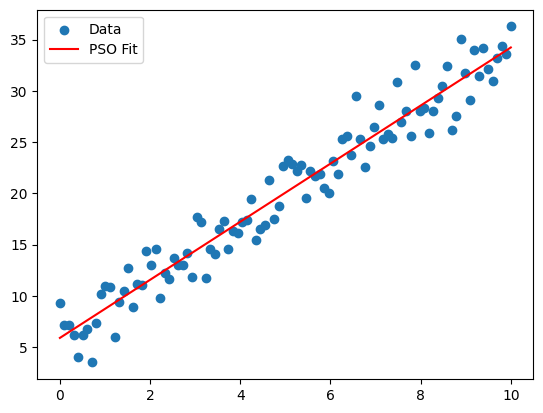

In [23]:
import numpy as np
import pyswarms as ps
import matplotlib.pyplot as plt

# --- 1. Generate Synthetic Time Series (y = 3x + 5) ---
t = np.linspace(0, 10, 100)
y_true = 3 * t + 5 + np.random.normal(0, 2, 100) # Added noise

# --- 2. Define MSE Objective ---
def mse_objective(particles):
    # We are trying to find the optimal m (slope) and c (intercept)
    # particle[i] = [m, c]
    losses = []
    for i in range(particles.shape[0]):
        m, c = particles[i]
        y_pred = m * t + c
        mse = np.mean((y_true - y_pred)**2)
        losses.append(mse)
    return np.array(losses)

# --- 3. Run PSO ---
options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
optimizer_ts = ps.single.GlobalBestPSO(n_particles=30, dimensions=2, options=options)
cost_ts, pos_ts = optimizer_ts.optimize(mse_objective, iters=100, verbose=False)

print(f"True Parameters: m=3, c=5")
print(f"PSO Found:       m={pos_ts[0]:.2f}, c={pos_ts[1]:.2f}")

# Optional: Plot
plt.scatter(t, y_true, label='Data')
plt.plot(t, pos_ts[0]*t + pos_ts[1], color='red', label='PSO Fit')
plt.legend()
plt.show()

### 4. Optimization using NiaPy
This cell explores the `niapy` library as an alternative to `pyswarms`. It sets up a task to minimize the Sphere function and runs the `ParticleSwarmOptimization` algorithm provided by the package.

In [ ]:
# This cell demonstrates using 'niapy', an alternative library to 'pyswarms'
# You may need to run: pip install niapy

from niapy.algorithms.basic import ParticleSwarmOptimization
from niapy.task import Task
from niapy.problems import Sphere

print("Exploring NiaPy Package...")

# Define a task: Minimize Sphere function with 3 dimensions
task = Task(problem=Sphere(dimension=3), max_iters=100)

# Initialize NiaPy PSO algorithm
algo = ParticleSwarmOptimization(population_size=30, c1=2.0, c2=2.0, w=0.7)

# Run optimization
best_score, best_solution = algo.run(task)

print(f"NiaPy Best Solution: {best_solution}")
print(f"NiaPy Best Score: {best_score}")

SyntaxError: incomplete input (3765613215.py, line 21)

### 5. Feature Selection using Binary PSO
This cell applies Binary PSO for feature selection on the Breast Cancer dataset. The objective is to find a subset of features that maximizes the accuracy of a Logistic Regression classifier (by minimizing $1 - \text{accuracy}$).

In [ ]:
import numpy as np
import pyswarms as ps
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# --- 1. Load Medical Data (Breast Cancer) ---
data = load_breast_cancer()
X, y = data.data, data.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- 2. Define Feature Selection Objective ---
def feature_selection_objective(x):
    # x is a binary mask (1 = select, 0 = ignore)
    n_particles = x.shape[0]
    j = []
    for i in range(n_particles):
        features = x[i]
        
        # Penalty if no features are selected
        if np.count_nonzero(features) == 0:
            j.append(1.0)
            continue
            
        # Select specific columns from dataset
        X_tr_sub = X_train[:, features == 1]
        X_te_sub = X_test[:, features == 1]
        
        # Train a quick classifier
        clf = LogisticRegression(solver='liblinear')
        clf.fit(X_tr_sub, y_train)
        score = clf.score(X_te_sub, y_test)
        
        # We want to maximize accuracy, so we minimize (1 - accuracy)
        j.append(1.0 - score)
    return np.array(j)

# --- 3. Run Binary PSO ---
# FIXED: changed k to 5 (must be less than n_particles which is 15)
options_bin = {'c1': 0.5, 'c2': 0.5, 'w':0.9, 'k': 5, 'p':2}
optimizer_fs = ps.discrete.BinaryPSO(n_particles=15, dimensions=30, options=options_bin)

cost_fs, pos_fs = optimizer_fs.optimize(feature_selection_objective, iters=20, verbose=False)

selected_features = np.where(pos_fs == 1)[0]
print(f"Total Features: {X.shape[1]}")
print(f"Selected Features ({len(selected_features)}): {selected_features}")
print(f"Best Accuracy Achieved: {(1 - cost_fs):.2%}")

Total Features: 30
Selected Features (18): [ 1  3  4  6  8 13 14 17 18 19 20 22 23 24 26 27 28 29]
Best Accuracy Achieved: 98.83%


### 6. Data Clustering using PSO
This cell uses PSO to perform clustering on the Breast Cancer dataset. The particles represent the coordinates of cluster centroids, and the objective is to minimize the Sum of Squared Errors (SSE) between data points and their nearest centroids.

In [ ]:
import numpy as np
import pyswarms as ps
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import pairwise_distances_argmin_min

# --- 1. Load Data ---
data = load_breast_cancer()
X_cluster = data.data
n_clusters = 2 # Malignant vs Benign
n_features = X_cluster.shape[1]

# --- 2. Define Clustering Objective (SSE) ---
def clustering_objective(particles):
    costs = []
    for particle in particles:
        # Reshape the flat particle back into (n_clusters, n_features) centroids
        centroids = particle.reshape(n_clusters, n_features)
        
        # Assign every data point to the nearest centroid
        _, dists = pairwise_distances_argmin_min(X_cluster, centroids)
        
        # Calculate Sum of Squared Errors (SSE)
        costs.append(np.sum(dists**2))
    return np.array(costs)

# --- 3. Setup Bounds and Run PSO ---
# Bounds help the swarm stay within the data range
min_val = X_cluster.min(axis=0).min()
max_val = X_cluster.max(axis=0).max()
dims = n_clusters * n_features
bounds_cluster = (min_val * np.ones(dims), max_val * np.ones(dims))

options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
optimizer_cl = ps.single.GlobalBestPSO(n_particles=20, dimensions=dims, options=options, bounds=bounds_cluster)

cost_cl, pos_cl = optimizer_cl.optimize(clustering_objective, iters=50, verbose=False)

print(f"Final Clustering Cost (SSE): {cost_cl:.2f}")

Final Clustering Cost (SSE): 32451633740.31
